In [1]:
# =========================================================
# STEP 1: Load 1320 as source (labeled), split 1440 as target
# target train (unlabeled) and target test (labeled)
# =========================================================

import os, glob
import numpy as np
import scipy.io as sio
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit

np.random.seed(42)

base1320 = r"E:\New Paper Work 2\Vibration_1320"
base1440 = r"E:\New Paper Work 2\Vibration_1440"

class_names = ["BF", "GF", "N", "TF"]
class_to_id = {"BF":0, "GF":1, "N":2, "TF":3}

folders1320 = {"BF":"Vib_BF1320_1","GF":"Vib_GF1320_1","N":"Vib_N1320_1","TF":"Vib_TF1320_1"}
folders1440 = {"BF":"Vib_BF1440_1","GF":"Vib_GF1440_1","N":"Vib_N1440_1","TF":"Vib_TF1440_1"}

def load_domain(base_path, folder_map, rpm_value):
    X, Y, D, FS, paths = [], [], [], [], []
    for cls in class_names:
        folder = os.path.join(base_path, folder_map[cls])
        files = sorted(glob.glob(os.path.join(folder, "*.mat")))
        print(f"{rpm_value} rpm | {cls} | files = {len(files)}")

        for fp in files:
            mat = sio.loadmat(fp)
            if ("signals" not in mat) or ("fs" not in mat):
                raise KeyError(f"Missing signals or fs in: {fp}")

            sig = np.array(mat["signals"], dtype=np.float32)
            fs_val = float(np.squeeze(mat["fs"]))

            if sig.ndim != 2:
                raise ValueError(f"signals not 2D in: {fp}, shape={sig.shape}")
            if sig.shape[0] != 2:
                raise ValueError(f"signals first dim must be 2 in: {fp}, shape={sig.shape}")

            X.append(sig)
            Y.append(cls)
            D.append(rpm_value)
            FS.append(fs_val)
            paths.append(fp)

    return X, Y, D, FS, paths

# Load source and target
Xs, Ys, Ds, FSs, Ps = load_domain(base1320, folders1320, 1320)
Xt, Yt, Dt, FSt, Pt = load_domain(base1440, folders1440, 1440)

print("\nLoaded summary")
print("Source 1320 samples:", len(Xs))
print("Target 1440 samples:", len(Xt))

print("\nCounts per class source:", dict(Counter(Ys)))
print("Counts per class target:", dict(Counter(Yt)))

# Split target into target train (unlabeled during training) and target test (held out labeled)
y_target_ids = np.array([class_to_id[y] for y in Yt], dtype=np.int64)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_train_t, idx_test_t = next(sss.split(np.zeros(len(y_target_ids)), y_target_ids))

Xt_train = [Xt[i] for i in idx_train_t]
Yt_train = [Yt[i] for i in idx_train_t]
FSt_train = [FSt[i] for i in idx_train_t]
Pt_train = [Pt[i] for i in idx_train_t]

Xt_test = [Xt[i] for i in idx_test_t]
Yt_test = [Yt[i] for i in idx_test_t]
FSt_test = [FSt[i] for i in idx_test_t]
Pt_test = [Pt[i] for i in idx_test_t]

print("\nTarget split")
print("Target train (unlabeled) samples:", len(Xt_train))
print("Target test  (labeled) samples  :", len(Xt_test))

print("\nCounts per class target train:", dict(Counter(Yt_train)))
print("Counts per class target test :", dict(Counter(Yt_test)))

# Sanity checks
print("\nSignal shape source example:", Xs[0].shape)
print("Signal shape target example:", Xt[0].shape)
print("Unique fs source:", sorted(list(set([round(v, 6) for v in FSs])))[:5])
print("Unique fs target:", sorted(list(set([round(v, 6) for v in FSt])))[:5])


1320 rpm | BF | files = 112
1320 rpm | GF | files = 111
1320 rpm | N | files = 116
1320 rpm | TF | files = 112
1440 rpm | BF | files = 112
1440 rpm | GF | files = 110
1440 rpm | N | files = 112
1440 rpm | TF | files = 112

Loaded summary
Source 1320 samples: 451
Target 1440 samples: 446

Counts per class source: {'BF': 112, 'GF': 111, 'N': 116, 'TF': 112}
Counts per class target: {'BF': 112, 'GF': 110, 'N': 112, 'TF': 112}

Target split
Target train (unlabeled) samples: 356
Target test  (labeled) samples  : 90

Counts per class target train: {'GF': 88, 'N': 89, 'BF': 90, 'TF': 89}
Counts per class target test : {'GF': 22, 'N': 23, 'TF': 23, 'BF': 22}

Signal shape source example: (2, 25600)
Signal shape target example: (2, 25600)
Unique fs source: [25600.0]
Unique fs target: [25600.0]


In [2]:
# =========================================================
# STEP 2: Physics features (global + patch) for source and target
# + normalize using SOURCE only (no target leakage)
# =========================================================

import numpy as np
from scipy.signal import welch
import math
from sklearn.preprocessing import StandardScaler

PATCH_SIZE = 256
N_PER_SEG = 1024
BANDS = [(0, 500), (500, 2000), (2000, 6000)]

def rms_energy(x):
    return np.sqrt(np.mean(x**2) + 1e-12)

def band_energy_ratios(x, fs, bands, nperseg=N_PER_SEG):
    f, Pxx = welch(x, fs=fs, nperseg=nperseg, noverlap=nperseg//2)
    Pxx = Pxx + 1e-12
    total = np.sum(Pxx)
    bers = []
    for (lo, hi) in bands:
        idx = (f >= lo) & (f <= hi)
        bers.append(float(np.sum(Pxx[idx]) / total))
    return bers

def spectral_centroid_norm(x, fs, nperseg=N_PER_SEG):
    f, Pxx = welch(x, fs=fs, nperseg=nperseg, noverlap=nperseg//2)
    Pxx = Pxx + 1e-12
    centroid = float(np.sum(f * Pxx) / np.sum(Pxx))
    nyq = fs / 2.0
    return centroid / (nyq + 1e-12)

def tkeo_stats(x):
    x0 = x[1:-1]
    psi = x0**2 - x[:-2] * x[2:]
    psi = psi.astype(np.float64)
    return float(np.mean(np.abs(psi))), float(np.var(psi))

def permutation_entropy(x, order=5, delay=1, normalize=True, downsample=5):
    x = x[::downsample]
    x = np.asarray(x, dtype=np.float64)
    n = len(x)
    if n < order * delay + 1:
        return 0.0

    patterns = {}
    for i in range(n - delay * (order - 1)):
        window = x[i : i + delay * order : delay]
        key = tuple(np.argsort(window))
        patterns[key] = patterns.get(key, 0) + 1

    counts = np.array(list(patterns.values()), dtype=np.float64)
    p = counts / (np.sum(counts) + 1e-12)
    pe = -np.sum(p * np.log(p + 1e-12))

    if normalize:
        pe /= np.log(math.factorial(order) + 1e-12)
    return float(pe)

def physics_vector_1ch(x, fs):
    feats = []
    feats.append(rms_energy(x))                            # 1
    feats.extend(band_energy_ratios(x, fs, BANDS))         # 3
    feats.append(spectral_centroid_norm(x, fs))            # 1
    mu, var = tkeo_stats(x)                                # 2
    feats.append(mu)
    feats.append(var)
    feats.append(permutation_entropy(x, order=5, delay=1)) # 1
    return np.array(feats, dtype=np.float32)               # total 8

def physics_global_2ch(sig2ch, fs):
    per_ch = []
    for ch in range(sig2ch.shape[0]):
        per_ch.append(physics_vector_1ch(sig2ch[ch], fs))
    per_ch = np.stack(per_ch, axis=0)  # (2, 8)

    mean_feats = per_ch.mean(axis=0)   # (8,)
    std_feats  = per_ch.std(axis=0)    # (8,)
    g = np.concatenate([mean_feats, std_feats], axis=0)  # (16,)
    return g.astype(np.float32)

def physics_patch_2ch(sig2ch, fs, patch_size=PATCH_SIZE):
    # (T, 4): energy, centroid, tkeo_mu, perm_ent on mean signal
    x = sig2ch.mean(axis=0)
    L = x.shape[0]
    T = L // patch_size
    x = x[:T * patch_size].reshape(T, patch_size)

    patch_feats = []
    for t in range(T):
        xt = x[t]
        e = rms_energy(xt)
        c = spectral_centroid_norm(xt, fs, nperseg=min(256, len(xt)))
        mu, _ = tkeo_stats(xt)
        pe = permutation_entropy(xt, order=4, delay=1, downsample=1)
        patch_feats.append([e, c, mu, pe])

    return np.array(patch_feats, dtype=np.float32)  # (T,4)

def extract_all(X_list, FS_list):
    Pg = []
    Pp = []
    for i in range(len(X_list)):
        Pg.append(physics_global_2ch(X_list[i], FS_list[i]))
        Pp.append(physics_patch_2ch(X_list[i], FS_list[i]))
    Pg = np.vstack(Pg)
    Pp = np.stack(Pp, axis=0)
    return Pg, Pp

# --------- Extract ----------
Pg_s, Pp_s = extract_all(Xs, FSs)
Pg_tu, Pp_tu = extract_all(Xt_train, FSt_train)   # target unlabeled
Pg_tt, Pp_tt = extract_all(Xt_test, FSt_test)     # target test

print("Global physics shapes (source, tgt_unl, tgt_test):",
      Pg_s.shape, Pg_tu.shape, Pg_tt.shape)
print("Patch physics shapes  (source, tgt_unl, tgt_test):",
      Pp_s.shape, Pp_tu.shape, Pp_tt.shape)

# --------- Normalize using SOURCE only ----------
scaler = StandardScaler()
Pg_s_norm = scaler.fit_transform(Pg_s)
Pg_tu_norm = scaler.transform(Pg_tu)
Pg_tt_norm = scaler.transform(Pg_tt)

print("\nNormalization check (source): mean≈0 first5:", np.round(Pg_s_norm.mean(axis=0)[:5], 3))
print("Normalization check (source): std≈1  first5:", np.round(Pg_s_norm.std(axis=0)[:5], 3))

print("\nAny NaN global:", np.isnan(Pg_s_norm).any(), np.isnan(Pg_tu_norm).any(), np.isnan(Pg_tt_norm).any())
print("Any NaN patch :", np.isnan(Pp_s).any(), np.isnan(Pp_tu).any(), np.isnan(Pp_tt).any())
print("Patch T check:", Pp_s.shape[1], "(should be 100)")


Global physics shapes (source, tgt_unl, tgt_test): (451, 16) (356, 16) (90, 16)
Patch physics shapes  (source, tgt_unl, tgt_test): (451, 100, 4) (356, 100, 4) (90, 100, 4)

Normalization check (source): mean≈0 first5: [ 0. -0.  0.  0.  0.]
Normalization check (source): std≈1  first5: [1. 1. 1. 1. 1.]

Any NaN global: False False False
Any NaN patch : False False False
Patch T check: 100 (should be 100)


In [3]:
# =========================================================
# STEP 3: Build datasets and loaders for Domain Adaptation
# =========================================================

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------- encode labels ----------
class_to_id = {"BF":0, "GF":1, "N":2, "TF":3}

ys = np.array([class_to_id[y] for y in Ys], dtype=np.int64)
yt_train = np.array([class_to_id[y] for y in Yt_train], dtype=np.int64)  # will not be used in training
yt_test  = np.array([class_to_id[y] for y in Yt_test],  dtype=np.int64)

# domain labels: source=0, target=1
ds = np.zeros(len(Xs), dtype=np.int64)
dt_unl = np.ones(len(Xt_train), dtype=np.int64)
dt_test = np.ones(len(Xt_test), dtype=np.int64)

# ---------- stack signals ----------
Xs_np = np.stack(Xs, axis=0).astype(np.float32)
Xt_unl_np = np.stack(Xt_train, axis=0).astype(np.float32)
Xt_test_np = np.stack(Xt_test, axis=0).astype(np.float32)

print("\nSignal shapes:")
print("Source:", Xs_np.shape)
print("Target unlabeled:", Xt_unl_np.shape)
print("Target test:", Xt_test_np.shape)

# ---------- dataset ----------
class DomainDataset(Dataset):
    def __init__(self, X, y, d, Pg, Pp, use_labels=True):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.d = torch.tensor(d, dtype=torch.long)
        self.Pg = torch.tensor(Pg, dtype=torch.float32)
        self.Pp = torch.tensor(Pp, dtype=torch.float32)
        self.use_labels = use_labels

    def __len__(self):
        return len(self.d)

    def __getitem__(self, idx):
        if self.use_labels:
            return self.X[idx], self.y[idx], self.d[idx], self.Pg[idx], self.Pp[idx]
        else:
            # y returned but ignored in training for target unlabeled
            return self.X[idx], self.y[idx], self.d[idx], self.Pg[idx], self.Pp[idx]

# Source labeled dataset
src_dataset = DomainDataset(Xs_np, ys, ds, Pg_s_norm, Pp_s, use_labels=True)

# Target unlabeled dataset
tgt_unl_dataset = DomainDataset(Xt_unl_np, yt_train, dt_unl, Pg_tu_norm, Pp_tu, use_labels=False)

# Target test dataset (labeled, only evaluation)
tgt_test_dataset = DomainDataset(Xt_test_np, yt_test, dt_test, Pg_tt_norm, Pp_tt, use_labels=True)

# ---------- dataloaders ----------
BATCH_SIZE = 16

src_loader = DataLoader(src_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
tgt_unl_loader = DataLoader(tgt_unl_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
tgt_test_loader = DataLoader(tgt_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ---------- sanity check ----------
xs_b, ys_b, ds_b, pgs_b, pps_b = next(iter(src_loader))
xt_b, yt_b, dt_b, pgt_b, ppt_b = next(iter(tgt_unl_loader))

print("\nBatch sanity:")
print("Source X:", xs_b.shape, "y:", ys_b.shape, "d:", ds_b.shape, "Pg:", pgs_b.shape, "Pp:", pps_b.shape)
print("Target X:", xt_b.shape, "y:", yt_b.shape, "d:", dt_b.shape, "Pg:", pgt_b.shape, "Pp:", ppt_b.shape)
print("Unique domain labels in source batch:", torch.unique(ds_b))
print("Unique domain labels in target batch:", torch.unique(dt_b))


Using device: cpu

Signal shapes:
Source: (451, 2, 25600)
Target unlabeled: (356, 2, 25600)
Target test: (90, 2, 25600)

Batch sanity:
Source X: torch.Size([16, 2, 25600]) y: torch.Size([16]) d: torch.Size([16]) Pg: torch.Size([16, 16]) Pp: torch.Size([16, 100, 4])
Target X: torch.Size([16, 2, 25600]) y: torch.Size([16]) d: torch.Size([16]) Pg: torch.Size([16, 16]) Pp: torch.Size([16, 100, 4])
Unique domain labels in source batch: tensor([0])
Unique domain labels in target batch: tensor([1])


In [4]:
# =========================================================
# STEP 4: Model = Physics Adaptive SSM + Domain Head (GRL) + CORAL support
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------- Gradient Reversal ----------
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lam * grad_output, None

def grl(x, lam=1.0):
    return GradReverse.apply(x, lam)

# ---------- Patch embedding ----------
class PatchEmbed1D(nn.Module):
    def __init__(self, patch_size=256, in_ch=2, emb_dim=64):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Linear(in_ch * patch_size, emb_dim)

    def forward(self, x):
        B, C, L = x.shape
        T = L // self.patch_size
        x = x[:, :, :T * self.patch_size]
        x = x.view(B, C, T, self.patch_size).permute(0, 2, 1, 3).contiguous()
        x = x.view(B, T, C * self.patch_size)
        return self.proj(x)  # (B,T,D)

# ---------- Stable SSM ----------
class StableSSM(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.log_A = nn.Parameter(torch.zeros(dim))
        self.B = nn.Parameter(torch.randn(dim) * 0.1)
        self.C = nn.Parameter(torch.randn(dim) * 0.1)
        self.gate = nn.Sequential(nn.Linear(dim, dim), nn.Sigmoid())
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        B, T, D = x.shape
        h = torch.zeros(B, D, device=x.device)
        A = -torch.exp(self.log_A)

        outs = []
        for t in range(T):
            xt = x[:, t]
            g = self.gate(xt)
            h_new = torch.tanh(A * h + self.B * xt)
            h = g * h_new + (1 - g) * h
            yt = self.C * h
            outs.append(yt.unsqueeze(1))

        y = torch.cat(outs, dim=1)
        return self.norm(y)

# ---------- RPM aware physics gate (domain condition) ----------
class DomainAdaptivePhysicsGate(nn.Module):
    def __init__(self, phys_dim=16, emb_dim=64):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.zeros(phys_dim))
        self.dom_embed = nn.Embedding(2, phys_dim)  # source=0, target=1

        self.mlp = nn.Sequential(
            nn.Linear(phys_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Sigmoid()
        )

    def forward(self, f, phys, dom):
        dom_bias = self.dom_embed(dom)
        sigma = torch.exp(self.log_sigma) + 1e-6
        phys_scaled = phys / sigma
        phys_cond = phys_scaled + dom_bias
        g = self.mlp(phys_cond)
        return f * (1.0 + g)

# ---------- Backbone ----------
class PhysAdaptiveSSMBackbone(nn.Module):
    def __init__(self, emb_dim=64, phys_dim=16):
        super().__init__()
        self.patch = PatchEmbed1D(patch_size=256, emb_dim=emb_dim)
        self.ssm1 = StableSSM(emb_dim)
        self.ssm2 = StableSSM(emb_dim)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.phys_gate = DomainAdaptivePhysicsGate(phys_dim, emb_dim)

    def forward(self, x, phys, dom):
        z0 = self.patch(x)         # (B,T,D)
        z1 = self.ssm1(z0)         # (B,T,D)
        z2 = self.ssm2(z1)         # (B,T,D)

        z_patch = z2               # patch embeddings

        f = z2.transpose(1,2)      # (B,D,T)
        f = self.pool(f).squeeze(-1)
        f = F.normalize(f, dim=1)
        f = self.phys_gate(f, phys, dom)
        f = F.normalize(f, dim=1)

        return f, z_patch, z1

# ---------- Full model with fault head and domain head ----------
class DASSMModel(nn.Module):
    def __init__(self, emb_dim=64, phys_dim=16, num_classes=4):
        super().__init__()
        self.backbone = PhysAdaptiveSSMBackbone(emb_dim, phys_dim)
        self.fault_head = nn.Linear(emb_dim, num_classes)
        self.domain_head = nn.Sequential(
            nn.Linear(emb_dim, emb_dim//2),
            nn.ReLU(),
            nn.Linear(emb_dim//2, 2)
        )

    def forward(self, x, phys, dom, grl_lam=1.0):
        f, z_patch, z_early = self.backbone(x, phys, dom)
        fault_logits = self.fault_head(f)

        # domain prediction with GRL
        f_rev = grl(f, grl_lam)
        dom_logits = self.domain_head(f_rev)

        return fault_logits, dom_logits, f, z_patch, z_early

model = DASSMModel().to(device)

# ---------- Physics projection 16 -> 64 for alignment loss ----------
phys_proj = nn.Sequential(
    nn.Linear(16, 64),
    nn.ReLU(),
    nn.Linear(64, 64)
).to(device)

# ---------- sanity forward ----------
xs_b, ys_b, ds_b, pgs_b, pps_b = next(iter(src_loader))
xt_b, yt_b, dt_b, pgt_b, ppt_b = next(iter(tgt_unl_loader))

xs_b, ds_b, pgs_b = xs_b.to(device), ds_b.to(device), pgs_b.to(device)
xt_b, dt_b, pgt_b = xt_b.to(device), dt_b.to(device), pgt_b.to(device)

with torch.no_grad():
    flog_s, dlog_s, fs, zp_s, ze_s = model(xs_b, pgs_b, ds_b, grl_lam=1.0)
    flog_t, dlog_t, ft, zp_t, ze_t = model(xt_b, pgt_b, dt_b, grl_lam=1.0)

print("\nSanity check outputs")
print("Fault logits source:", flog_s.shape)
print("Domain logits source:", dlog_s.shape)
print("Feat source:", fs.shape)
print("Patch emb source:", zp_s.shape)
print("Early emb source:", ze_s.shape)

print("\nFault logits target:", flog_t.shape)
print("Domain logits target:", dlog_t.shape)
print("Feat target:", ft.shape)
print("Patch emb target:", zp_t.shape)
print("Early emb target:", ze_t.shape)

print("\nAny NaN in features:", torch.isnan(fs).any().item(), torch.isnan(ft).any().item())


Using device: cpu

Sanity check outputs
Fault logits source: torch.Size([16, 4])
Domain logits source: torch.Size([16, 2])
Feat source: torch.Size([16, 64])
Patch emb source: torch.Size([16, 100, 64])
Early emb source: torch.Size([16, 100, 64])

Fault logits target: torch.Size([16, 4])
Domain logits target: torch.Size([16, 2])
Feat target: torch.Size([16, 64])
Patch emb target: torch.Size([16, 100, 64])
Early emb target: torch.Size([16, 100, 64])

Any NaN in features: False False


In [5]:
# =========================================================
# STEP 5: Losses for Domain Adaptation (GRL + CORAL + Physics)
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

ce_fault = nn.CrossEntropyLoss()
ce_domain = nn.CrossEntropyLoss()

def l2norm(x, eps=1e-8):
    return x / (torch.norm(x, dim=-1, keepdim=True) + eps)

# ---------- CORAL loss ----------
def coral_loss(source, target):
    """
    source: (B, D)
    target: (B, D)
    """
    d = source.size(1)

    # covariance
    src = source - source.mean(dim=0, keepdim=True)
    tgt = target - target.mean(dim=0, keepdim=True)

    cov_s = (src.T @ src) / (source.size(0) - 1 + 1e-12)
    cov_t = (tgt.T @ tgt) / (target.size(0) - 1 + 1e-12)

    return torch.mean((cov_s - cov_t) ** 2)

# ---------- Physics losses ----------
def patch_physics_consistency_loss(z_patch, P_patch):
    """
    z_patch: (B,T,D) SSM patches
    P_patch: (B,T,4) physics patch descriptors
    """
    z = l2norm(z_patch)
    p = l2norm(P_patch)

    loss = 0.0
    cnt = 0
    T = z_patch.shape[1]
    for t in range(T - 1):
        dz = torch.norm(z[:, t] - z[:, t+1], dim=1)
        dp = torch.norm(p[:, t] - p[:, t+1], dim=1)
        loss += F.mse_loss(dz, dp)
        cnt += 1
    return loss / max(cnt, 1)

def early_physics_regularization(z_early):
    dz = z_early[:, 1:] - z_early[:, :-1]
    return torch.mean(dz ** 2)

def global_physics_alignment_loss(feats, P_global, phys_proj):
    feats_n = l2norm(feats)
    phys_emb = phys_proj(P_global)
    phys_emb_n = l2norm(phys_emb)
    return torch.mean(1.0 - torch.sum(feats_n * phys_emb_n, dim=1))

# ---------- Sanity compute losses on one source+target batch ----------
model.train()
phys_proj.train()

xs_b, ys_b, ds_b, pgs_b, pps_b = next(iter(src_loader))
xt_b, yt_b, dt_b, pgt_b, ppt_b = next(iter(tgt_unl_loader))

xs_b, ys_b, ds_b = xs_b.to(device), ys_b.to(device), ds_b.to(device)
pgs_b, pps_b = pgs_b.to(device), pps_b.to(device)

xt_b, dt_b = xt_b.to(device), dt_b.to(device)
pgt_b, ppt_b = pgt_b.to(device), ppt_b.to(device)

# forward
fault_s, dom_s, fs, zp_s, ze_s = model(xs_b, pgs_b, ds_b, grl_lam=1.0)
fault_t, dom_t, ft, zp_t, ze_t = model(xt_b, pgt_b, dt_b, grl_lam=1.0)

# losses
L_fault = ce_fault(fault_s, ys_b)

dom_labels = torch.cat([ds_b, dt_b], dim=0)
dom_logits = torch.cat([dom_s, dom_t], dim=0)
L_domain = ce_domain(dom_logits, dom_labels)

L_coral = coral_loss(fs, ft)

L_patch_s = patch_physics_consistency_loss(zp_s, pps_b)
L_early_s = early_physics_regularization(ze_s)
L_global_s = global_physics_alignment_loss(fs, pgs_b, phys_proj)

print("Loss sanity:")
print("Fault CE       :", float(L_fault.detach()))
print("Domain CE      :", float(L_domain.detach()))
print("CORAL          :", float(L_coral.detach()))
print("Patch physics  :", float(L_patch_s.detach()))
print("Early physics  :", float(L_early_s.detach()))
print("Global physics :", float(L_global_s.detach()))

print("Any NaN check:", any([
    torch.isnan(L_fault), torch.isnan(L_domain), torch.isnan(L_coral),
    torch.isnan(L_patch_s), torch.isnan(L_early_s), torch.isnan(L_global_s)
]))


Loss sanity:
Fault CE       : 1.3859037160873413
Domain CE      : 0.706128716468811
CORAL          : 1.3896879863750655e-05
Patch physics  : 1.5377037525177002
Early physics  : 0.6515499353408813
Global physics : 0.9571688175201416
Any NaN check: False


In [6]:
# =========================================================
# STEP 6: Train DASSM (fault + domain + CORAL + physics)
# =========================================================

import torch
import torch.optim as optim
import math

EPOCHS = 20
PRINT_EARLY = 3   # run only first 3 epochs now

optimizer = optim.Adam(
    list(model.parameters()) + list(phys_proj.parameters()),
    lr=1e-3
)

def ramp(epoch, T=10, max_w=1.0):
    return max_w * (1.0 - math.exp(-epoch / T))

def evaluate_on_target_test():
    model.eval()
    phys_proj.eval()

    correct = 0
    total = 0
    loss_sum = 0.0

    with torch.no_grad():
        for x, y, d, Pg, Pp in tgt_test_loader:
            x = x.to(device)
            y = y.to(device)
            d = d.to(device)
            Pg = Pg.to(device)

            fault_logits, dom_logits, f, z_patch, z_early = model(x, Pg, d, grl_lam=0.0)
            L = ce_fault(fault_logits, y)

            loss_sum += L.item()
            pred = fault_logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    return loss_sum / len(tgt_test_loader), correct / total


print("\nStarting Domain Adaptation Training...\n")

for epoch in range(EPOCHS):

    model.train()
    phys_proj.train()

    src_iter = iter(src_loader)
    tgt_iter = iter(tgt_unl_loader)

    steps = min(len(src_loader), len(tgt_unl_loader))

    total_loss = 0.0
    total_fault = 0.0
    total_domain = 0.0
    total_coral = 0.0

    # weights
    lam_domain = ramp(epoch, 5, 0.5)
    lam_coral  = ramp(epoch, 5, 5.0)     # scaled because coral can be small
    lam_patch  = ramp(epoch, 8, 0.1)
    lam_early  = ramp(epoch, 8, 0.05)
    lam_global = ramp(epoch, 8, 0.05)

    # GRL strength schedule
    grl_lam = ramp(epoch, 5, 1.0)

    for _ in range(steps):
        xs_b, ys_b, ds_b, pgs_b, pps_b = next(src_iter)
        xt_b, yt_b, dt_b, pgt_b, ppt_b = next(tgt_iter)

        xs_b, ys_b, ds_b = xs_b.to(device), ys_b.to(device), ds_b.to(device)
        pgs_b, pps_b = pgs_b.to(device), pps_b.to(device)

        xt_b, dt_b = xt_b.to(device), dt_b.to(device)
        pgt_b, ppt_b = pgt_b.to(device), ppt_b.to(device)

        optimizer.zero_grad()

        # forward source and target
        fault_s, dom_s, fs, zp_s, ze_s = model(xs_b, pgs_b, ds_b, grl_lam=grl_lam)
        fault_t, dom_t, ft, zp_t, ze_t = model(xt_b, pgt_b, dt_b, grl_lam=grl_lam)

        # fault loss on source only
        L_fault = ce_fault(fault_s, ys_b)

        # domain loss on both
        dom_labels = torch.cat([ds_b, dt_b], dim=0)
        dom_logits = torch.cat([dom_s, dom_t], dim=0)
        L_dom = ce_domain(dom_logits, dom_labels)

        # CORAL
        L_coral = coral_loss(fs, ft)

        # physics losses on source only (labels not needed)
        L_patch = patch_physics_consistency_loss(zp_s, pps_b)
        L_early = early_physics_regularization(ze_s)
        L_global = global_physics_alignment_loss(fs, pgs_b, phys_proj)

        # total
        L = (
            L_fault
            + lam_domain * L_dom
            + lam_coral  * L_coral
            + lam_patch  * L_patch
            + lam_early  * L_early
            + lam_global * L_global
        )

        L.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += L.item()
        total_fault += L_fault.item()
        total_domain += L_dom.item()
        total_coral += L_coral.item()

    # evaluate on target test
    te_loss, te_acc = evaluate_on_target_test()

    print(
        f"[Epoch {epoch+1:02d}] "
        f"Train L {total_loss/steps:.4f} | Fault {total_fault/steps:.4f} "
        f"| Dom {total_domain/steps:.4f} | CORAL {total_coral/steps:.6f} "
        f"|| TargetTest Loss {te_loss:.4f} Acc {te_acc:.4f}"
    )

    if epoch == PRINT_EARLY - 1:
        break



Starting Domain Adaptation Training...

[Epoch 01] Train L 1.2223 | Fault 1.2223 | Dom 0.7065 | CORAL 0.000027 || TargetTest Loss 1.1772 Acc 0.8444
[Epoch 02] Train L 1.0882 | Fault 0.9966 | Dom 0.6993 | CORAL 0.000044 || TargetTest Loss 1.0434 Acc 0.9111
[Epoch 03] Train L 0.9955 | Fault 0.8361 | Dom 0.6748 | CORAL 0.000045 || TargetTest Loss 0.9231 Acc 0.8667


In [7]:
# =========================================================
# STEP 7: Full training with best-model tracking (save best)
# =========================================================

import torch
import torch.optim as optim
import math
import os

SAVE_DIR = "DASSM_Physics_Best"
os.makedirs(SAVE_DIR, exist_ok=True)
best_path = os.path.join(SAVE_DIR, "best_dassm.pt")

EPOCHS = 20

optimizer = optim.Adam(
    list(model.parameters()) + list(phys_proj.parameters()),
    lr=1e-3
)

def ramp(epoch, T=10, max_w=1.0):
    return max_w * (1.0 - math.exp(-epoch / T))

def evaluate_on_target_test():
    model.eval()
    phys_proj.eval()

    correct = 0
    total = 0
    loss_sum = 0.0

    with torch.no_grad():
        for x, y, d, Pg, Pp in tgt_test_loader:
            x = x.to(device)
            y = y.to(device)
            d = d.to(device)
            Pg = Pg.to(device)

            fault_logits, dom_logits, f, z_patch, z_early = model(x, Pg, d, grl_lam=0.0)
            L = ce_fault(fault_logits, y)

            loss_sum += L.item()
            pred = fault_logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    return loss_sum / len(tgt_test_loader), correct / total

best_acc = 0.0
best_epoch = -1

print("\nTraining with best-model tracking...\n")

for epoch in range(EPOCHS):

    model.train()
    phys_proj.train()

    src_iter = iter(src_loader)
    tgt_iter = iter(tgt_unl_loader)
    steps = min(len(src_loader), len(tgt_unl_loader))

    # weights (warmup)
    lam_domain = ramp(epoch, 5, 0.5)
    lam_coral  = ramp(epoch, 5, 5.0)
    lam_patch  = ramp(epoch, 8, 0.1)
    lam_early  = ramp(epoch, 8, 0.05)
    lam_global = ramp(epoch, 8, 0.05)
    grl_lam    = ramp(epoch, 5, 1.0)

    total_L = 0.0

    for _ in range(steps):
        xs_b, ys_b, ds_b, pgs_b, pps_b = next(src_iter)
        xt_b, yt_b, dt_b, pgt_b, ppt_b = next(tgt_iter)

        xs_b, ys_b, ds_b = xs_b.to(device), ys_b.to(device), ds_b.to(device)
        pgs_b, pps_b = pgs_b.to(device), pps_b.to(device)

        xt_b, dt_b = xt_b.to(device), dt_b.to(device)
        pgt_b, ppt_b = pgt_b.to(device), ppt_b.to(device)

        optimizer.zero_grad()

        fault_s, dom_s, fs, zp_s, ze_s = model(xs_b, pgs_b, ds_b, grl_lam=grl_lam)
        fault_t, dom_t, ft, zp_t, ze_t = model(xt_b, pgt_b, dt_b, grl_lam=grl_lam)

        L_fault = ce_fault(fault_s, ys_b)

        dom_labels = torch.cat([ds_b, dt_b], dim=0)
        dom_logits = torch.cat([dom_s, dom_t], dim=0)
        L_dom = ce_domain(dom_logits, dom_labels)

        L_c = coral_loss(fs, ft)

        L_patch = patch_physics_consistency_loss(zp_s, pps_b)
        L_early = early_physics_regularization(ze_s)
        L_global = global_physics_alignment_loss(fs, pgs_b, phys_proj)

        L = (
            L_fault
            + lam_domain * L_dom
            + lam_coral  * L_c
            + lam_patch  * L_patch
            + lam_early  * L_early
            + lam_global * L_global
        )

        L.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_L += L.item()

    te_loss, te_acc = evaluate_on_target_test()

    if te_acc > best_acc:
        best_acc = te_acc
        best_epoch = epoch + 1
        torch.save({
            "model": model.state_dict(),
            "phys_proj": phys_proj.state_dict(),
            "best_epoch": best_epoch,
            "best_acc": best_acc
        }, best_path)

    print(f"[Epoch {epoch+1:02d}] TrainLoss {total_L/steps:.4f} | "
          f"TargetTest Loss {te_loss:.4f} Acc {te_acc:.4f} | "
          f"Best {best_acc:.4f} (Epoch {best_epoch})")

print("\nTraining done.")
print("Best accuracy:", best_acc, "at epoch", best_epoch)
print("Saved best model to:", best_path)



Training with best-model tracking...

[Epoch 01] TrainLoss 0.7199 | TargetTest Loss 0.8281 Acc 0.8778 | Best 0.8778 (Epoch 1)
[Epoch 02] TrainLoss 0.7012 | TargetTest Loss 0.7782 Acc 0.8333 | Best 0.8778 (Epoch 1)
[Epoch 03] TrainLoss 0.6783 | TargetTest Loss 0.7162 Acc 0.8444 | Best 0.8778 (Epoch 1)
[Epoch 04] TrainLoss 0.6566 | TargetTest Loss 0.5873 Acc 0.9556 | Best 0.9556 (Epoch 4)
[Epoch 05] TrainLoss 0.6632 | TargetTest Loss 0.5319 Acc 0.9889 | Best 0.9889 (Epoch 5)
[Epoch 06] TrainLoss 0.6561 | TargetTest Loss 0.5032 Acc 0.9889 | Best 0.9889 (Epoch 5)
[Epoch 07] TrainLoss 0.6355 | TargetTest Loss 0.4764 Acc 0.9889 | Best 0.9889 (Epoch 5)
[Epoch 08] TrainLoss 0.6089 | TargetTest Loss 0.4124 Acc 0.9889 | Best 0.9889 (Epoch 5)
[Epoch 09] TrainLoss 0.5892 | TargetTest Loss 0.3656 Acc 0.9889 | Best 0.9889 (Epoch 5)
[Epoch 10] TrainLoss 0.5763 | TargetTest Loss 0.3347 Acc 1.0000 | Best 1.0000 (Epoch 10)
[Epoch 11] TrainLoss 0.5543 | TargetTest Loss 0.2994 Acc 1.0000 | Best 1.0000 (E

Saving figures to: E:\New Paper Work 2\DASSM_Physics_FinalFigures
Loaded checkpoint: DASSM_Physics_Best\best_dassm.pt
Best epoch: 10 Best acc: 1.0

Re-running training to record loss curves (for plots)...



C:\Users\saifu\AppData\Local\Temp\ipykernel_16096\503460195.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_path, map_location=device)


[Epoch 01] TrainLoss 1.2565 | TargetTestLoss 1.1861 | Acc 0.8556
[Epoch 02] TrainLoss 1.1426 | TargetTestLoss 1.0503 | Acc 0.8889
[Epoch 03] TrainLoss 1.0406 | TargetTestLoss 0.9276 | Acc 0.9111
[Epoch 04] TrainLoss 0.9557 | TargetTestLoss 0.8315 | Acc 0.9333
[Epoch 05] TrainLoss 0.8824 | TargetTestLoss 0.7153 | Acc 1.0000
[Epoch 06] TrainLoss 0.8336 | TargetTestLoss 0.6285 | Acc 0.9889
[Epoch 07] TrainLoss 0.7967 | TargetTestLoss 0.5664 | Acc 0.9889
[Epoch 08] TrainLoss 0.7422 | TargetTestLoss 0.4874 | Acc 0.9889
[Epoch 09] TrainLoss 0.6972 | TargetTestLoss 0.4035 | Acc 1.0000
[Epoch 10] TrainLoss 0.6752 | TargetTestLoss 0.3938 | Acc 0.9889
[Epoch 11] TrainLoss 0.6477 | TargetTestLoss 0.3757 | Acc 1.0000
[Epoch 12] TrainLoss 0.6117 | TargetTestLoss 0.3140 | Acc 1.0000
[Epoch 13] TrainLoss 0.5882 | TargetTestLoss 0.2635 | Acc 1.0000
[Epoch 14] TrainLoss 0.5712 | TargetTestLoss 0.2386 | Acc 1.0000
[Epoch 15] TrainLoss 0.5479 | TargetTestLoss 0.2030 | Acc 1.0000
[Epoch 16] TrainLoss 0.52

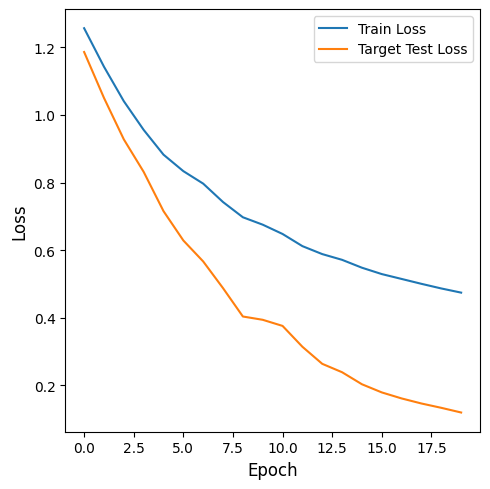

Saved: E:\New Paper Work 2\DASSM_Physics_FinalFigures\loss_curves_2000dpi.png

Confusion matrix:
 [[22  0  0  0]
 [ 0 22  0  0]
 [ 0  0 23  0]
 [ 0  0  0 23]]

Classification report:

              precision    recall  f1-score   support

          BF       1.00      1.00      1.00        22
          GF       1.00      1.00      1.00        22
           N       1.00      1.00      1.00        23
          TF       1.00      1.00      1.00        23

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



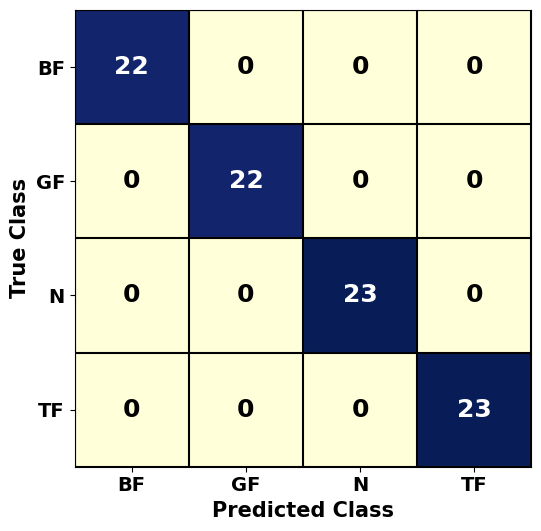

Saved: E:\New Paper Work 2\DASSM_Physics_FinalFigures\confusion_matrix_2000dpi.png


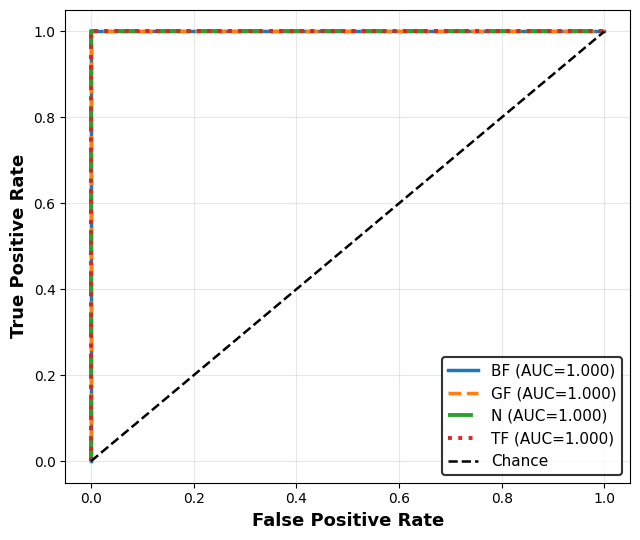

Saved: E:\New Paper Work 2\DASSM_Physics_FinalFigures\roc_curves_2000dpi.png
AUCs: {'BF': 1.0, 'GF': 1.0, 'N': 1.0, 'TF': 1.0}


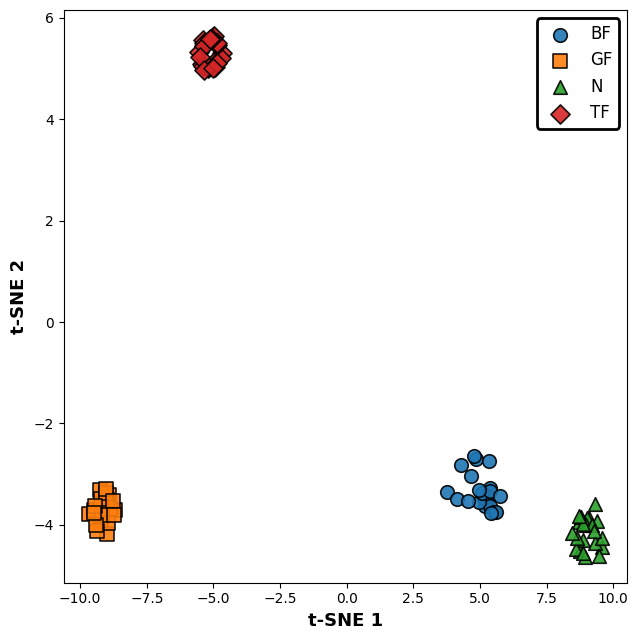

Saved: E:\New Paper Work 2\DASSM_Physics_FinalFigures\tsne_2000dpi.png

All figures saved in: E:\New Paper Work 2\DASSM_Physics_FinalFigures


In [12]:
# =========================================================
# STEP 8: Final Evaluation + High Quality Figures (2000 dpi)
# - Train loss and TargetTest loss curves
# - Confusion Matrix
# - ROC curves
# - t-SNE
# =========================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

# -----------------------------
# Save folder
# -----------------------------
RESULT_DIR = r"E:\New Paper Work 2\DASSM_Physics_FinalFigures"
os.makedirs(RESULT_DIR, exist_ok=True)
print("Saving figures to:", RESULT_DIR)

# -----------------------------
# Load best checkpoint
# -----------------------------
best_path = os.path.join("DASSM_Physics_Best", "best_dassm.pt")
ckpt = torch.load(best_path, map_location=device)

model.load_state_dict(ckpt["model"])
phys_proj.load_state_dict(ckpt["phys_proj"])

model.eval()
phys_proj.eval()

print("Loaded checkpoint:", best_path)
print("Best epoch:", ckpt.get("best_epoch", None), "Best acc:", ckpt.get("best_acc", None))

class_names = ["BF", "GF", "N", "TF"]
n_classes = len(class_names)

# =========================================================
# (A) Re-run training for curves (loss tracking)
# We reproduce the same training process but store losses
# =========================================================
import math
import torch.optim as optim

EPOCHS = 20

# Re-initialize a fresh model for curves
model_curve = DASSMModel().to(device)
phys_proj_curve = torch.nn.Sequential(
    torch.nn.Linear(16, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 64)
).to(device)

optimizer = optim.Adam(
    list(model_curve.parameters()) + list(phys_proj_curve.parameters()),
    lr=1e-3
)

def ramp(epoch, T=10, max_w=1.0):
    return max_w * (1.0 - math.exp(-epoch / T))

train_losses = []
test_losses = []
test_accs = []

def eval_target_curve():
    model_curve.eval()
    phys_proj_curve.eval()
    correct = 0
    total = 0
    loss_sum = 0.0
    with torch.no_grad():
        for x, y, d, Pg, Pp in tgt_test_loader:
            x = x.to(device)
            y = y.to(device)
            d = d.to(device)
            Pg = Pg.to(device)
            fault_logits, dom_logits, f, z_patch, z_early = model_curve(x, Pg, d, grl_lam=0.0)
            L = ce_fault(fault_logits, y)
            loss_sum += L.item()
            pred = fault_logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return loss_sum / len(tgt_test_loader), correct / total

print("\nRe-running training to record loss curves (for plots)...\n")

for epoch in range(EPOCHS):
    model_curve.train()
    phys_proj_curve.train()

    src_iter = iter(src_loader)
    tgt_iter = iter(tgt_unl_loader)
    steps = min(len(src_loader), len(tgt_unl_loader))

    lam_domain = ramp(epoch, 5, 0.5)
    lam_coral  = ramp(epoch, 5, 5.0)
    lam_patch  = ramp(epoch, 8, 0.1)
    lam_early  = ramp(epoch, 8, 0.05)
    lam_global = ramp(epoch, 8, 0.05)
    grl_lam    = ramp(epoch, 5, 1.0)

    total_L = 0.0

    for _ in range(steps):
        xs_b, ys_b, ds_b, pgs_b, pps_b = next(src_iter)
        xt_b, yt_b, dt_b, pgt_b, ppt_b = next(tgt_iter)

        xs_b, ys_b, ds_b = xs_b.to(device), ys_b.to(device), ds_b.to(device)
        pgs_b, pps_b = pgs_b.to(device), pps_b.to(device)
        xt_b, dt_b = xt_b.to(device), dt_b.to(device)
        pgt_b, ppt_b = pgt_b.to(device), ppt_b.to(device)

        optimizer.zero_grad()

        fault_s, dom_s, fs, zp_s, ze_s = model_curve(xs_b, pgs_b, ds_b, grl_lam=grl_lam)
        fault_t, dom_t, ft, zp_t, ze_t = model_curve(xt_b, pgt_b, dt_b, grl_lam=grl_lam)

        L_fault = ce_fault(fault_s, ys_b)

        dom_labels = torch.cat([ds_b, dt_b], dim=0)
        dom_logits = torch.cat([dom_s, dom_t], dim=0)
        L_dom = ce_domain(dom_logits, dom_labels)

        L_c = coral_loss(fs, ft)

        L_patch = patch_physics_consistency_loss(zp_s, pps_b)
        L_early = early_physics_regularization(ze_s)
        L_global = global_physics_alignment_loss(fs, pgs_b, phys_proj_curve)

        L = (
            L_fault
            + lam_domain * L_dom
            + lam_coral  * L_c
            + lam_patch  * L_patch
            + lam_early  * L_early
            + lam_global * L_global
        )

        L.backward()
        torch.nn.utils.clip_grad_norm_(model_curve.parameters(), 5.0)
        optimizer.step()

        total_L += L.item()

    avg_train_loss = total_L / steps
    te_loss, te_acc = eval_target_curve()

    train_losses.append(avg_train_loss)
    test_losses.append(te_loss)
    test_accs.append(te_acc)

    print(f"[Epoch {epoch+1:02d}] TrainLoss {avg_train_loss:.4f} | TargetTestLoss {te_loss:.4f} | Acc {te_acc:.4f}")

# Plot loss curves
loss_path = os.path.join(RESULT_DIR, "loss_curves_2000dpi.png")

plt.figure(figsize=(5,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Target Test Loss")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(loss_path, dpi=2000, bbox_inches="tight")
plt.show()
print("Saved:", loss_path)

# =========================================================
# (B) Evaluation on target test with best saved model
# =========================================================
y_true, y_pred, y_prob = [], [], []
features_all, labels_all = [], []

with torch.no_grad():
    for x, y, d, Pg, Pp in tgt_test_loader:
        x = x.to(device)
        Pg = Pg.to(device)
        d = d.to(device)

        logits, dom_logits, feats, z_patch, z_early = model(x, Pg, d, grl_lam=0.0)
        prob = torch.softmax(logits, dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(torch.argmax(logits, dim=1).cpu().numpy())
        y_prob.extend(prob.cpu().numpy())

        features_all.append(feats.cpu().numpy())
        labels_all.append(y.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

features_all = np.vstack(features_all)
labels_all = np.hstack(labels_all)

# =========================================================
# (C) Confusion matrix (2000 dpi)
# =========================================================
# =========================================================
# (C) Confusion matrix – enhanced (2000 dpi)
# =========================================================
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm_path = os.path.join(RESULT_DIR, "confusion_matrix_2000dpi.png")

plt.figure(figsize=(5.5, 5.5))
im = plt.imshow(cm, cmap="YlGnBu")

# Axis ticks
ticks = np.arange(n_classes)
plt.xticks(ticks, class_names, fontsize=14, fontweight="bold")
plt.yticks(ticks, class_names, fontsize=14, fontweight="bold")

# Draw grid lines
plt.gca().set_xticks(np.arange(-.5, n_classes, 1), minor=True)
plt.gca().set_yticks(np.arange(-.5, n_classes, 1), minor=True)
plt.grid(which="minor", color="black", linestyle="-", linewidth=1.5)
plt.tick_params(which="minor", bottom=False, left=False)

thresh = cm.max() * 0.55
for i in range(n_classes):
    for j in range(n_classes):
        plt.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            fontsize=18, fontweight="bold",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.xlabel("Predicted Class", fontsize=15, fontweight="bold")
plt.ylabel("True Class", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(cm_path, dpi=2000, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)


# =========================================================
# (D) ROC curves (2000 dpi)
# =========================================================
# =========================================================
# (D) ROC curves – styled (2000 dpi)
# =========================================================
roc_path = os.path.join(RESULT_DIR, "roc_curves_2000dpi.png")
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

line_styles = ["-", "--", "-.", ":"]
line_widths = [2.5, 2.5, 2.8, 2.8]

plt.figure(figsize=(6.5, 5.5))
auc_list = []

for c in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, c], y_prob[:, c])
    roc_auc = auc(fpr, tpr)
    auc_list.append(roc_auc)

    plt.plot(
        fpr, tpr,
        linestyle=line_styles[c % len(line_styles)],
        linewidth=line_widths[c % len(line_widths)],
        label=f"{class_names[c]} (AUC={roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", linewidth=1.8, label="Chance")

plt.xlabel("False Positive Rate", fontsize=13, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=13, fontweight="bold")

leg = plt.legend(fontsize=11, frameon=True)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.5)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(roc_path, dpi=2000, bbox_inches="tight")
plt.show()

print("Saved:", roc_path)
print("AUCs:", {class_names[i]: round(auc_list[i], 4) for i in range(n_classes)})


# =========================================================
# (E) t-SNE (2000 dpi)
# =========================================================
# =========================================================
# (E) t-SNE – markers + bold legend (2000 dpi)
# =========================================================
tsne_path = os.path.join(RESULT_DIR, "tsne_2000dpi.png")

tsne = TSNE(
    n_components=2,
    perplexity=25,
    init="pca",
    learning_rate="auto",
    random_state=42
)
Z = tsne.fit_transform(features_all)

markers = ["o", "s", "^", "D"]  # circle, square, triangle, diamond

plt.figure(figsize=(6.5, 6.5))
for c, name in enumerate(class_names):
    idx = labels_all == c
    plt.scatter(
        Z[idx, 0], Z[idx, 1],
        s=95,
        marker=markers[c % len(markers)],
        edgecolors="black",
        linewidths=1.2,
        alpha=0.9,
        label=name
    )

plt.xlabel("t-SNE 1", fontsize=13, fontweight="bold")
plt.ylabel("t-SNE 2", fontsize=13, fontweight="bold")

leg = plt.legend(fontsize=12, frameon=True)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(2.0)   # bold legend box
leg.get_frame().set_alpha(1.0)

plt.tight_layout()
plt.savefig(tsne_path, dpi=2000, bbox_inches="tight")
plt.show()

print("Saved:", tsne_path)


print("\nAll figures saved in:", RESULT_DIR)
